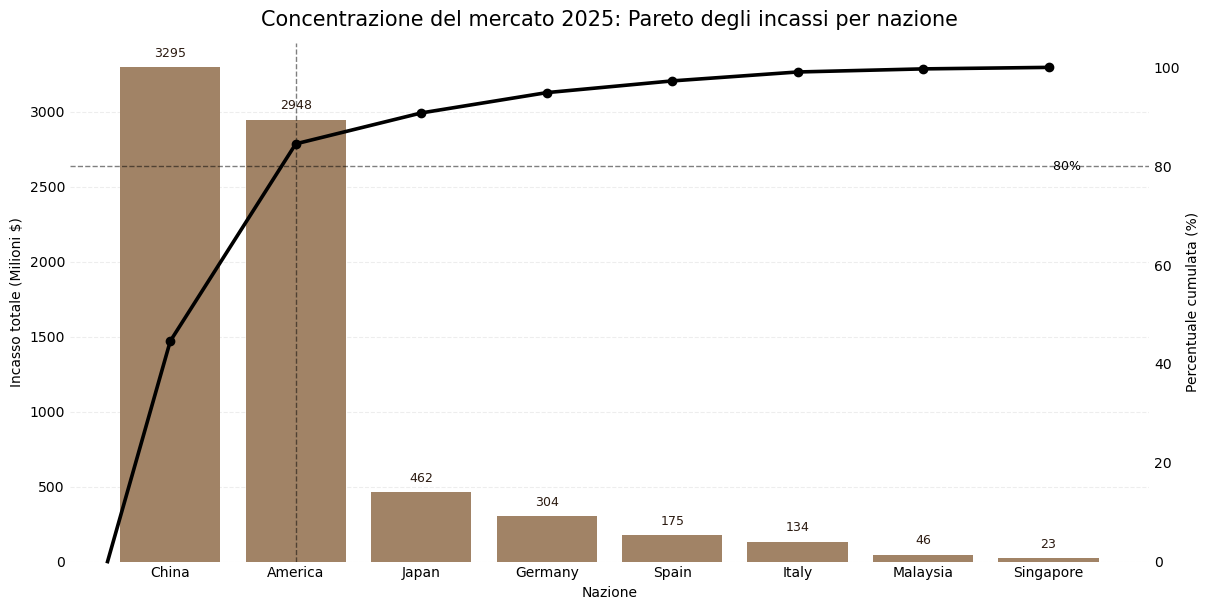

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def parse_money(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s.lower() in ["", "-", "nan", "none"]:
        return np.nan
    s = re.sub(r"[€$]", "", s)
    s = s.replace(" ", "")
    s = re.sub(r"[^0-9,\.]", "", s)
    if s == "":
        return np.nan
    if "," in s and "." in s:
        s = s.replace(".", "").replace(",", ".")
    else:
        if s.count(".") >= 2 and "," not in s:
            s = s.replace(".", "")
        elif s.count(",") >= 2 and "." not in s:
            s = s.replace(",", "")
        else:
            if "," in s and "." not in s:
                s = s.replace(".", "").replace(",", ".")
            elif "." in s and "," not in s:
                parts = s.split(".")
                if len(parts[-1]) == 3 and all(len(p) <= 3 for p in parts[:-1]):
                    s = "".join(parts)
    try:
        return float(s)
    except:
        return np.nan

# Lettura e preparazione dati
raw = pd.read_csv("Nazione.csv")
raw.columns = raw.columns.str.strip()

header_row = raw.iloc[0].tolist()
cols = []
for i, c in enumerate(raw.columns):
    v = header_row[i]
    v = "" if pd.isna(v) else str(v).strip()
    cols.append(v if v != "" else c)

df = raw.iloc[1:].copy()
df.columns = cols

df = df.loc[:, [c for c in df.columns if not str(c).lower().startswith("unnamed")]]

col_movie = df.columns[0]
df = df.rename(columns={col_movie: "Movie"})
df["Movie"] = df["Movie"].astype(str).str.strip()

for c in df.columns:
    if c != "Movie":
        df[c] = df[c].apply(parse_money)

df = df.fillna(0.0)

tot_country = df.drop(columns=["Movie"]).sum(axis=0)
tot_country = tot_country[tot_country > 0].sort_values(ascending=False)

if len(tot_country) == 0:
    raise ValueError("Nazione.csv non contiene valori numerici validi.")

paesi = tot_country.index.tolist()
valori = (tot_country.values / 1e6)

cum = np.cumsum(valori)
cum_pct = 100 * cum / cum[-1]

x = np.arange(len(paesi))
x_line = np.concatenate(([-0.5], x))
y_line = np.concatenate(([0], cum_pct))

colore_unico = "#A18366"

fig, ax1 = plt.subplots(figsize=(12.2, 6.2))

bars = ax1.bar(x, valori, color=colore_unico, edgecolor="none")

ax1.set_title("Concentrazione del mercato 2025: Pareto degli incassi per nazione", fontsize=15, pad=12)
ax1.set_xlabel("Nazione")
ax1.set_ylabel("Incasso totale (Milioni $)")

ax1.set_xticks(x)
ax1.set_xticklabels(paesi, rotation=0)

ax1.set_axisbelow(True)
ax1.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.22)

for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.tick_params(length=0)

for b, v in zip(bars, valori):
    ax1.text(b.get_x() + b.get_width()/2,
             v + max(valori)*0.015,
             f"{v:.0f}",
             ha="center",
             va="bottom",
             fontsize=9,
             color="#2b1a10")

ax2 = ax1.twinx()

# --- FIX: Disegna la linea continua (senza marker all'origine) e i marker solo sui dati ---
# 1. Disegna solo la linea continua, partendo da x=-0.5 (clip_on=False evita i tagli)
ax2.plot(x_line, y_line, linewidth=2.6, color="black", clip_on=False)
# 2. Aggiunge i pallini neri SOLO sulle coordinate dei paesi (x)
ax2.plot(x, cum_pct, linewidth=0, marker="o", markersize=6, color="black", clip_on=False)

ax2.set_ylabel("Percentuale cumulata (%)")
ax2.set_ylim(0, 105)
ax2.tick_params(length=0)

for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.axhline(80, linestyle="--", linewidth=1, alpha=0.5, color="black")
ax2.text(len(x)-1, 80, " 80%", va="center", fontsize=9)

k = int(np.argmax(cum_pct >= 80))
ax2.axvline(k, linestyle="--", linewidth=1, alpha=0.5, color="black")

# --- FIX: Allarga i limiti dell'asse X per dare respiro al punto di origine ---
ax1.set_xlim(-0.8, len(paesi) - 0.2)

plt.tight_layout()
plt.show()